In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv('iris.csv')

In [3]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
from sklearn.preprocessing import LabelEncoder

In [5]:
encoder = LabelEncoder()

In [7]:
df['species'] = encoder.fit_transform(df['species'])

In [8]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [9]:
df = df[df['species'] != 0][['sepal_width','petal_length','species']]

In [10]:
df.head()

,sepal_width,petal_length,species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

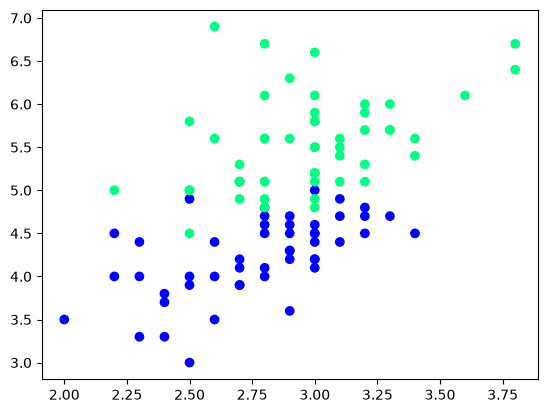

In [12]:
plt.scatter(df['sepal_width'],df['petal_length'],c=df['species'],cmap='winter')

In [13]:
df_train = df.iloc[:60,:].sample(10)
df_train

,sepal_width,petal_length,species
82,2.7,3.9,1
106,2.5,4.5,2
91,3.0,4.6,1
54,2.8,4.6,1
98,2.5,3.0,1
102,3.0,5.9,2
94,2.7,4.2,1
88,3.0,4.1,1
78,2.9,4.5,1
57,2.4,3.3,1


In [14]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [15]:
df_train

,sepal_width,petal_length,species
96,2.9,4.2,1
89,2.5,4.0,1
93,2.3,3.3,1
102,3.0,5.9,2
85,3.4,4.5,1
80,2.4,3.8,1
101,2.7,5.1,2
106,2.5,4.5,2
144,3.3,5.7,2
99,2.8,4.1,1


In [16]:
df_val

,sepal_width,petal_length,species
134,2.6,5.6,2
95,3.0,4.2,1
114,2.8,5.1,2
71,2.8,4.0,1
128,2.8,5.6,2


In [17]:
df_test

,sepal_width,petal_length,species
64,2.9,3.6,1
149,3.0,5.1,2
118,2.6,6.9,2
148,3.4,5.4,2
83,2.7,5.1,1


In [18]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [19]:
y_test

array([2, 1, 2, 1, 2])

# Case 1 - Bagging

In [20]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal_width,petal_length,species
85,3.4,4.5,1
89,2.5,4.0,1
89,2.5,4.0,1
93,2.3,3.3,1
89,2.5,4.0,1
85,3.4,4.5,1
106,2.5,4.5,2
96,2.9,4.2,1


In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

In [33]:
dt_bag1 = DecisionTreeClassifier()

In [34]:
def evaluate(model, X, y):
    model.fit(X, y)

    plt.figure(figsize=(5,4))
    plot_decision_regions(X.values, y.values, clf=model, legend=2)

    y_pred = model.predict(X)
    print("Accuracy =", accuracy_score(y, y_pred))

    plt.show()

Accuracy = 1.0


C:\Users\shrey\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


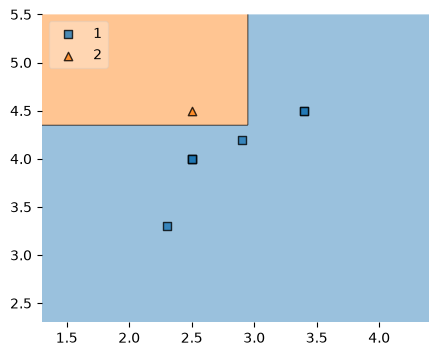

In [35]:
evaluate(dt_bag1,X,y)

In [36]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal_width,petal_length,species
102,3.0,5.9,2
101,2.7,5.1,2
99,2.8,4.1,1
85,3.4,4.5,1
80,2.4,3.8,1
85,3.4,4.5,1
93,2.3,3.3,1
80,2.4,3.8,1


Accuracy = 1.0


C:\Users\shrey\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


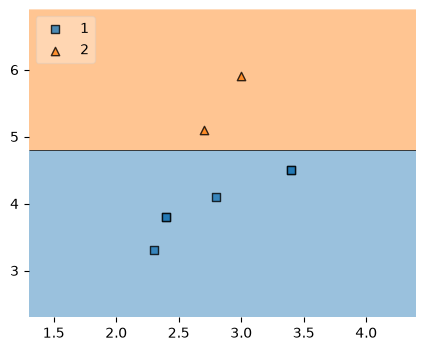

In [37]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [38]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal_width,petal_length,species
101,2.7,5.1,2
102,3.0,5.9,2
80,2.4,3.8,1
106,2.5,4.5,2
96,2.9,4.2,1
96,2.9,4.2,1
80,2.4,3.8,1
89,2.5,4.0,1


Accuracy = 1.0


C:\Users\shrey\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


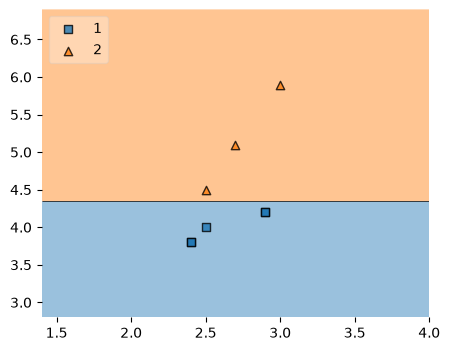

In [39]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

In [40]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))

In [42]:
df_test

,sepal_width,petal_length,species
64,2.9,3.6,1
149,3.0,5.1,2
118,2.6,6.9,2
148,3.4,5.4,2
83,2.7,5.1,1


In [43]:
print("Predictor 1",dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [2]
Predictor 3 [2]


C:\Users\shrey\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\shrey\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\shrey\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# Pasting

In [44]:
# Row sampling without replacement
df_train

,sepal_width,petal_length,species
96,2.9,4.2,1
89,2.5,4.0,1
93,2.3,3.3,1
102,3.0,5.9,2
85,3.4,4.5,1
80,2.4,3.8,1
101,2.7,5.1,2
106,2.5,4.5,2
144,3.3,5.7,2
99,2.8,4.1,1


In [45]:
df_train.sample(8)

,sepal_width,petal_length,species
106,2.5,4.5,2
93,2.3,3.3,1
99,2.8,4.1,1
101,2.7,5.1,2
144,3.3,5.7,2
89,2.5,4.0,1
85,3.4,4.5,1
102,3.0,5.9,2


# Random Subspaces

In [47]:
df1 = pd.read_csv('iris.csv')
df1 = df1.sample(10)

In [48]:
df1

,sepal_length,sepal_width,petal_length,petal_width,species
57,4.9,2.4,3.3,1.0,versicolor
63,6.1,2.9,4.7,1.4,versicolor
125,7.2,3.2,6.0,1.8,virginica
133,6.3,2.8,5.1,1.5,virginica
107,7.3,2.9,6.3,1.8,virginica
131,7.9,3.8,6.4,2.0,virginica
34,4.9,3.1,1.5,0.1,setosa
58,6.6,2.9,4.6,1.3,versicolor
138,6.0,3.0,4.8,1.8,virginica
83,6.0,2.7,5.1,1.6,versicolor


In [49]:
df1.sample(2,replace=True,axis=1)

,species,sepal_length
57,versicolor,4.9
63,versicolor,6.1
125,virginica,7.2
133,virginica,6.3
107,virginica,7.3
131,virginica,7.9
34,setosa,4.9
58,versicolor,6.6
138,virginica,6.0
83,versicolor,6.0


# Random Patches

In [50]:
df1

,sepal_length,sepal_width,petal_length,petal_width,species
57,4.9,2.4,3.3,1.0,versicolor
63,6.1,2.9,4.7,1.4,versicolor
125,7.2,3.2,6.0,1.8,virginica
133,6.3,2.8,5.1,1.5,virginica
107,7.3,2.9,6.3,1.8,virginica
131,7.9,3.8,6.4,2.0,virginica
34,4.9,3.1,1.5,0.1,setosa
58,6.6,2.9,4.6,1.3,versicolor
138,6.0,3.0,4.8,1.8,virginica
83,6.0,2.7,5.1,1.6,versicolor


In [51]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,sepal_width,species
63,2.9,versicolor
125,3.2,virginica
125,3.2,virginica
58,2.9,versicolor
58,2.9,versicolor
58,2.9,versicolor
138,3.0,virginica
57,2.4,versicolor
